# Chonkle: Codec Pipelines

**chonkle** is a codec pipeline library for encoding and decoding chunked data. Pipelines are directed acyclic graphs (DAGs) of codec steps. Each step can use a different backend: native Python (via numcodecs), core Wasm, or Component Model Wasm.

This notebook demonstrates a round-trip decode/encode of a COG tile using a two-step pipeline where the zlib step runs as a native Python codec and the TIFF predictor step runs as a Wasm codec. The same codec can ship as either a Core Wasm module or a Component Model Wasm component — chonkle handles both transparently.

## Setup

Start by importing the required libraries and preparing a test chunk from a real Sentinel-2 COG.

### Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from chunk_utils import cog_metadata, describe_bytes, download_cog, extract_tile

from chonkle.executor import run
from chonkle.pipeline import prepare
from chonkle.resolver import Resolver

### Download a COG

Let's grab a red band (B04) COG from [Earth Search](https://earth-search.aws.element84.com/v1). It's large, so the first run will take a moment. The file is saved to a `data/` directory next to the notebook, so subsequent runs will skip the download.

In [2]:
COG_URL = (
    "https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/"
    "sentinel-2-c1-l2a/10/T/FR/2023/12/"
    "S2B_T10TFR_20231223T190950_L2A/B04.tif"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
COG_PATH = DATA_DIR / "B04.tif"

if not COG_PATH.exists():
    download_cog(COG_URL, COG_PATH)
    print(f"Downloaded {COG_PATH}")
else:
    print(f"Already downloaded: {COG_PATH}")

Already downloaded: data/B04.tif


### Inspect the COG metadata

We can inspect the downloaded image metadata for information we'll need to build the pipeline definition. Key tags to note:

- **Compression**: 8 = DEFLATE
- **Predictor**: 2 = horizontal differencing
- **TileWidth / TileLength**: 1024
- **SampleFormat / BitsPerSample**: uint16

In [3]:
for name, value in cog_metadata(COG_PATH):
    print(f"{name}: {value}")

ImageWidth: 10980
ImageLength: 10980
BitsPerSample: 16
Compression: 8
PhotometricInterpretation: 1
SamplesPerPixel: 1
PlanarConfiguration: 1
Predictor: 2
TileWidth: 1024
TileLength: 1024
TileOffsets: (55962680, 57411167, 58810332, 60222446, 61651003, 63054996, 64463518, 66025043, 67523672, 68987825, 70439668, 71480485, 72831139, 74191906, 75556803, 76922917, 78346396, 79767466, 81177106, 82626646, 84045343, 85436959, 86443457, 87744763, 89128625, 90516041, 91896145, 93323921, 94699513, 96054131, 97398784, 98768288, 100117176, 101099165, 102475360, 103914015, 105337327, 106767167, 108155055, 109496290, 110853634, 112244713, 113588526, 114895196, 115881834, 117297939, 118737048, 120185270, 121620456, 123031867, 124402930, 125797422, 127166585, 128512496, 129847193, 130813023, 132267746, 133721219, 135168258, 136590051, 138004961, 139387400, 140792216, 142173401, 143531515, 144883653, 145909014, 147512228, 148965842, 150393926, 151820955, 153228408, 154629691, 156014882, 157380367, 158731

### Extract a tile (chunk)

Next, let's extract the raw bytes of tile 0 (the first 1024×1024 pixel block) to use as our test chunk. We'll use the SHA-256 hash as our reference for verifying round-trip fidelity.

In [4]:
chunk_bytes = extract_tile(COG_PATH, 0)
describe_bytes(chunk_bytes)

size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62


## Pipeline definition

A chonkle pipeline is a JSON document that defines a DAG of codec steps. Each step has a `codec_id` and a set of named input ports wired to pipeline inputs, constants, or outputs from other steps. The wiring reference format is:

- `input.<name>` — a pipeline-level input
- `constant.<name>` — a named constant (JSON-encoded as bytes at runtime)
- `<step_name>.<port>` — an output port from another step

The pipeline declares a `direction` ("encode" or "decode") indicating which direction the DAG was authored in. The same pipeline supports both directions: running in the authored direction executes steps in topological order, while running in the opposite direction inverts the DAG (reversed order, opposite codec function).

For this COG tile, the decode pipeline is:

1. **zlib** — DEFLATE decompression (bytes → bytes)
2. **predictor2** — undo TIFF horizontal differencing (bytes → bytes)

Codec parameters (`level`, `bytes_per_sample`, `width`) are declared as pipeline constants and wired to codec input ports.

In [5]:
wasm_path = Path("tiff-predictor-2-c.wasm").resolve()

pipeline = {
    "codec_id": "cog-zlib-predictor2",
    "direction": "decode",
    "inputs": {"bytes": {"type": "bytes"}},
    "constants": {
        "bytes_per_sample": {"type": "int", "value": 2},
        "width": {"type": "int", "value": 1024},
        "level": {"type": "int", "value": 9},
    },
    "sources": {"tiff-predictor-2": wasm_path.as_uri()},
    "outputs": {"bytes": "predictor2.bytes"},
    "steps": {
        "zlib": {
            "codec_id": "zlib",
            "inputs": {
                "bytes": "input.bytes",
                "level": "constant.level",
            },
        },
        "predictor2": {
            "codec_id": "tiff-predictor-2",
            "inputs": {
                "bytes": "zlib.bytes",
                "bytes_per_sample": "constant.bytes_per_sample",
                "width": "constant.width",
            },
        },
    },
}

### Embedded codec signatures

Every chonkle `.wasm` binary carries a `chonkle:signature` custom section with the codec's metadata: its `codec_id`, `implementation` name, and typed input/output port descriptors. The `detect_codec_type` function reads the binary header to distinguish Core Wasm modules from Component Model components.

In [6]:
import json

from chonkle.wasm_signature import detect_codec_type, read_signature

print(f"Backend: {detect_codec_type(wasm_path).value}\n")
print(json.dumps(read_signature(wasm_path), indent=2))

Backend: component

{
  "codec_id": "tiff-predictor-2",
  "implementation": "tiff-predictor-2-c",
  "inputs": {
    "bytes": {
      "type": "bytes",
      "required": true
    },
    "bytes_per_sample": {
      "type": "int",
      "required": true
    },
    "width": {
      "type": "int",
      "required": true
    }
  },
  "outputs": {
    "bytes": {
      "type": "bytes"
    }
  }
}


### Codec resolution

The `Resolver` maps each step's `codec_id` to an implementation. It checks a local codec store and a set of bundled native (numcodecs) codecs, selecting among available backends using a configurable preference order (default: native > core Wasm > Component Model Wasm). The pipeline's `sources` field provides download URIs for codecs not already available locally.

### Decode

To decode, we prepare the pipeline for the "decode" direction, then run it with the raw tile bytes as input. Since the pipeline was authored for "decode", this runs the steps in their declared order. The result is `dict[str, bytes]` — we convert to a numpy array afterward.

In [7]:
prepared = prepare(pipeline, "decode")
result = run(prepared, {"bytes": chunk_bytes})

arr = np.frombuffer(result["bytes"], dtype=np.uint16).reshape(1024, 1024)
print(f"shape: {arr.shape}  dtype: {arr.dtype}  min: {arr.min()}  max: {arr.max()}")

shape: (1024, 1024)  dtype: uint16  min: 0  max: 10552


Let's plot the decoded chunk as a 2D image.

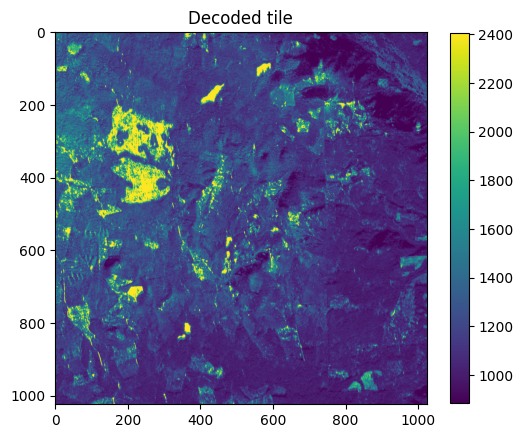

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
vmin, vmax = np.percentile(arr[arr > 0], [2, 98])
im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax)
ax.set_title("Decoded tile")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

### Encode and verify round trip

Encoding uses the same pipeline definition but prepared for the "encode" direction. Since the pipeline was authored for "decode", this inverts the execution: steps run in reversed order and each codec's `encode` function is called instead of `decode`. The result should be identical to the original tile bytes.

In [9]:
enc_prepared = prepare(pipeline, "encode")
encoded = run(enc_prepared, {"bytes": result["bytes"]})

describe_bytes(encoded["bytes"])
assert encoded["bytes"] == chunk_bytes, "Round-trip mismatch!"
print("Round trip: OK")

size: 1.381 MiB | sha256: 2c02e7e60074d6767ccb4c44de2da249d331fd82e107431e41cfe4069bae0d62
Round trip: OK


## Remote Wasm sources

Wasm codecs can be fetched from HTTPS URLs or OCI registries. Here we download the same `tiff-predictor-2` codec from each and verify that the decoded output matches.

### HTTPS

In [10]:
resolver_https = Resolver(
    force_sources={
        "tiff-predictor-2": (
            "https://github.com/cylf-dev/tiff-predictor-2-c/"
            "releases/download/v0.3.0/tiff-predictor-2-c.wasm"
        ),
    },
)

prepared_https = prepare(pipeline, "decode", resolver=resolver_https)
result_https = run(prepared_https, {"bytes": chunk_bytes})

assert result_https["bytes"] == result["bytes"]
print("Decoded bytes match: OK")

Decoded bytes match: OK


### OCI

The same codec can be pulled from an OCI registry by changing the URI scheme.

In [11]:
resolver_oci = Resolver(
    force_sources={
        "tiff-predictor-2": "oci://ghcr.io/cylf-dev/tiff-predictor-2-c:v0.3.0",
    },
)

prepared_oci = prepare(pipeline, "decode", resolver=resolver_oci)
result_oci = run(prepared_oci, {"bytes": chunk_bytes})

assert result_oci["bytes"] == result["bytes"]
print("Decoded bytes match: OK")

Decoded bytes match: OK


## Summary

chonkle codec pipelines are DAGs of codec steps defined in JSON, with typed ports wired together. A single pipeline definition supports both encode and decode via direction inversion. Codec resolution is automatic: the resolver picks the best available backend (native Python, core Wasm, or Component Model Wasm) based on a configurable preference order. Wasm codecs can be loaded from local files, HTTPS URLs, or OCI registries — and pipelines can embed their own source URIs to be fully self-describing.